# D01 · From a raw table to model-ready arrays

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Palmer Station penguins **as recorded in the field** (344 rows, awkward names, dates, comments, gaps) · IBM telco churn (7043 customers, mixed types, blank strings) |
| **You will learn** | Cleaning with intent · the unit of analysis · missing-value triage · `pd.factorize` -> index vectors -> `coords` · what index / dummy / sum-to-zero coding say about the **prior** · centring and scaling, and back-transforming with full uncertainty · leakage · outcome transforms and the retransformation trap · design matrices with `patsy`, rank checks · sufficient statistics · a `prepare()` function with assertions · saving a fit so it can be interpreted later |

Most "my model will not sample" and "my model gives nonsense" problems are **data-preparation
problems**. A PyMC model never sees your DataFrame. It consumes three things:

| The model eats | Example | Comes from |
|---|---|---|
| **arrays** of floats | `mass_kg`, a standardised `X` | numeric columns, after units, transforms and scaling are decided |
| **index vectors** of integers | `species_idx = [0, 0, 2, 1, ...]` | categorical columns, through a *fixed* mapping level -> integer |
| **coordinates** | `{"species": ["Adelie", "Chinstrap", "Gentoo"]}` | the same mapping, kept so every output is labelled |

Preparation is the disciplined path from a table to those three. None of it is neutral:
every choice on the path - the unit of a predictor, the reference level of a factor, whether
the outcome is logged - changes **what the priors mean**. This notebook walks the path once,
slowly, and shows the standard ways of falling off it.

This opens the **D-series** (data work), which sits beside the E-series (modelling
techniques). The models here are deliberately small and fast: the subject is the data.

In [1]:
import json
import tempfile
import time
from dataclasses import dataclass
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import patsy
import pymc as pm
import xarray as xr

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, pandas {pd.__version__}, patsy {patsy.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, pandas 3.0.6, patsy 1.0.3


## 1 · Look at the raw table before touching it

`data.load` only parses the file. Everything after that is a decision, so make it visibly.

In [2]:
data.describe("penguins_raw")
raw = data.load("penguins_raw")
raw.head(3).T

penguins_raw: 344 penguins as recorded in the field: messy column names, dates, comments, missing measurements.
  source: Gorman, Williams & Fraser (2014), Palmer Station LTER, via R `palmerpenguins` (raw field records).
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/palmerpenguins/penguins_raw.csv


rownames,1,2,3
studyName,PAL0708,PAL0708,PAL0708
Sample Number,1,2,3
Species,Adelie Penguin (Pygoscelis adeliae),Adelie Penguin (Pygoscelis adeliae),Adelie Penguin (Pygoscelis adeliae)
Region,Anvers,Anvers,Anvers
Island,Torgersen,Torgersen,Torgersen
Stage,"Adult, 1 Egg Stage","Adult, 1 Egg Stage","Adult, 1 Egg Stage"
Individual ID,N1A1,N1A2,N2A1
Clutch Completion,Yes,Yes,Yes
Date Egg,2007-11-11,2007-11-11,2007-11-16
Culmen Length (mm),39.1,39.5,40.3


An **audit table** is the cheapest tool in this notebook: one row per column with its type,
how much is missing, how much is *blank* (an empty or whitespace string is not `NaN`, and
`isna()` will not find it), and how many distinct values it has. Make one before cleaning
and one after; the difference is the documentation of what you did.

In [3]:
def audit(df):
    """One row per column: dtype, missing, blank strings, distinct values, an example."""
    is_text = [pd.api.types.is_string_dtype(df[c]) for c in df.columns]
    blank = [int((df[c].str.strip() == "").sum()) if t else 0 for c, t in zip(df.columns, is_text)]
    return pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing": df.isna().sum(),
            "blank": blank,
            "distinct": df.nunique(),
            "example": df.iloc[0].astype(str).str.slice(0, 28),
        }
    )


audit(raw)

,dtype,missing,blank,distinct,example
studyName,str,0,0,3,PAL0708
Sample Number,int64,0,0,152,1
Species,str,0,0,3,Adelie Penguin (Pygoscelis a
Region,str,0,0,1,Anvers
Island,str,0,0,3,Torgersen
Stage,str,0,0,1,"Adult, 1 Egg Stage"
Individual ID,str,0,0,190,N1A1
Clutch Completion,str,0,0,2,Yes
Date Egg,str,0,0,50,2007-11-11
Culmen Length (mm),float64,2,0,164,39.1


What the audit says, column by column:

- **Names** have spaces, brackets and units: `raw["Culmen Length (mm)"]` works, but
  attribute access, `patsy` formulas and `az.summary` labels all suffer. Rename once, with
  an explicit dictionary - not a regex - so the unit survives in the name (`_mm`, `_g`) and
  a changed upstream schema fails loudly.
- **`Region` and `Stage` have one distinct value.** They carry no information for a model,
  but they *define the population*: adult penguins at the one-egg stage near Anvers Island.
  Assert that they are constant, then drop them.
- **`Species`** is a long string with the Latin name. We want a short label for coords.
- **`Date Egg`** is text. **`Sex`** is upper-case text with gaps. **`Clutch Completion`** is
  Yes/No text. **`Comments`** is free text - mostly empty, and as we will see it explains
  *why* values are missing, which is worth more than the values.
- Four measurements are missing in 2 rows, sex in 11, the isotopes in 13-14.

In [4]:
RENAME = {
    "studyName": "study",
    "Sample Number": "sample_number",
    "Species": "species_full",
    "Region": "region",
    "Island": "island",
    "Stage": "stage",
    "Individual ID": "individual_id",
    "Clutch Completion": "clutch_completion",
    "Date Egg": "date_egg",
    "Culmen Length (mm)": "bill_length_mm",
    "Culmen Depth (mm)": "bill_depth_mm",
    "Flipper Length (mm)": "flipper_length_mm",
    "Body Mass (g)": "body_mass_g",
    "Sex": "sex",
    "Delta 15 N (o/oo)": "delta_15n",
    "Delta 13 C (o/oo)": "delta_13c",
    "Comments": "comments",
}
MEASUREMENTS = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
# generous physical limits: a value outside is a typo or a unit error, not a penguin
PLAUSIBLE = {
    "bill_length_mm": (25, 70),
    "bill_depth_mm": (10, 25),
    "flipper_length_mm": (150, 250),
    "body_mass_g": (2000, 7000),
}


def clean_penguins(raw):
    assert set(raw.columns) == set(RENAME), "upstream schema changed"
    df = raw.rename(columns=RENAME)

    # constant columns define the population; check, then drop
    for col in ["region", "stage"]:
        assert df[col].nunique() == 1, f"{col} is no longer constant"
    df = df.drop(columns=["region", "stage"])

    # "Adelie Penguin (Pygoscelis adeliae)" -> "Adelie". (.str.split().str[0] would also work, but in
    # pandas 3 it hands back an `object` column; the after-audit is how you notice such things.)
    df["species"] = df.species_full.str.extract(r"^(\w+)")[0]
    df["sex"] = df.sex.str.lower()
    df["clutch_completion"] = df.clutch_completion.map({"Yes": True, "No": False}).astype(bool)
    df["date_egg"] = pd.to_datetime(df.date_egg, format="%Y-%m-%d")  # explicit format: fail, do not guess
    df["year"] = df.date_egg.dt.year
    df["egg_day"] = (df.date_egg - pd.to_datetime(df.year.astype(str) + "-11-01")).dt.days  # days after 1 Nov
    df["nest"] = df.individual_id.str.extract(r"^(N\d+)A\d$")[0]

    for col, (lo, hi) in PLAUSIBLE.items():
        bad = df[col].notna() & ~df[col].between(lo, hi)
        assert not bad.any(), f"{int(bad.sum())} impossible values in {col}"
    assert df.nest.notna().all(), "individual_id does not follow the N<nest>A<adult> pattern"
    return df.drop(columns=["species_full"]).reset_index(drop=True)


peng_all = clean_penguins(raw)
audit(peng_all)

,dtype,missing,blank,distinct,example
study,str,0,0,3,PAL0708
sample_number,int64,0,0,152,1
island,str,0,0,3,Torgersen
individual_id,str,0,0,190,N1A1
clutch_completion,bool,0,0,2,True
date_egg,datetime64[us],0,0,50,2007-11-11 00:00:00
bill_length_mm,float64,2,0,164,39.1
bill_depth_mm,float64,2,0,80,18.7
flipper_length_mm,float64,2,0,55,181.0
body_mass_g,float64,2,0,94,3750.0


### What is a row?

The **unit of analysis** decides what "independent observations" means in the likelihood,
so it has to be settled from the data, not assumed from the file name.

In [5]:
key = ["study", "species", "island", "individual_id"]
print("exact duplicate rows:       ", int(peng_all.duplicated().sum()))
print("duplicates of the row key:  ", int(peng_all.duplicated(key).sum()))
print("distinct individual_id:     ", peng_all.individual_id.nunique(), "for", len(peng_all), "rows")
print("(species, id) pairs seen in more than one season:",
      int((peng_all.groupby(["species", "individual_id"]).study.nunique() > 1).sum()))
print("adults per (study, species, island, nest):",
      peng_all.groupby(["study", "species", "island", "nest"]).size().value_counts().to_dict())

exact duplicate rows:        0
duplicates of the row key:   0
distinct individual_id:      190 for 344 rows
(species, id) pairs seen in more than one season: 60
adults per (study, species, island, nest): {2: 172}


So `individual_id` is **not** a bird identifier. `N1A1` means "nest 1, adult 1" and the
label is reused across species and seasons; it is unique only together with study, species
and island. A row is **one adult of a breeding pair, at one nest, in one season**, and
every nest contributes exactly two rows - which is also why the file contains rows with no
measurements at all: the *nest* was recorded, the bird was not caught.

Two consequences. First, the two rows of a nest are mates, not independent draws; a model
that cared could add a nest effect (the index vector would come from the four-column key,
not from `nest` alone). Second, had we joined anything on `individual_id` alone we would
have silently multiplied rows. **Assert your key is unique before every merge.**

### Blank strings are not NaN (a larger table)

The telco table makes a point the penguins cannot. Audit first:

In [6]:
data.describe("telco")
telco_raw = data.load("telco")
audit(telco_raw).loc[["customerID", "SeniorCitizen", "tenure", "Contract", "MonthlyCharges", "TotalCharges", "Churn"]]

telco: Tenure (months), churn flag and contract details for 7043 customers.
  source: IBM sample data, Telco customer churn.
  url:    https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv


,dtype,missing,blank,distinct,example
customerID,str,0,0,7043,7590-VHVEG
SeniorCitizen,int64,0,0,2,0
tenure,int64,0,0,73,1
Contract,str,0,0,3,Month-to-month
MonthlyCharges,float64,0,0,1585,29.85
TotalCharges,str,0,11,6531,29.85
Churn,str,0,0,2,No


`TotalCharges` is a **string** column with 0 missing values - and 11 blanks. One
unparseable cell is enough for `read_csv` to give up on a numeric type. The reflex fix is
`pd.to_numeric(..., errors="coerce")`, which turns whatever it cannot read into `NaN`
without telling you what it was. Coerce, but then **look at exactly the rows that changed**:

In [7]:
total = pd.to_numeric(telco_raw.TotalCharges, errors="coerce")
changed = total.isna() & telco_raw.TotalCharges.notna()
print("cells that coercion turned into NaN:", int(changed.sum()),
      "- their raw values:", telco_raw.TotalCharges[changed].unique().tolist())
telco_raw.loc[changed, ["tenure", "Contract", "MonthlyCharges", "TotalCharges", "Churn"]].head()

cells that coercion turned into NaN: 11 - their raw values: [' ']


,tenure,Contract,MonthlyCharges,TotalCharges,Churn
488,0,Two year,52.55,,No
753,0,Two year,20.25,,No
936,0,Two year,80.85,,No
1082,0,Two year,25.75,,No
1340,0,Two year,56.05,,No


In [8]:
print("tenure of the blank rows:", telco_raw.tenure[changed].unique(),
      "| rows with tenure 0:", int((telco_raw.tenure == 0).sum()))

tenure of the blank rows: [0] | rows with tenure 0: 11


The blanks are exactly the customers with `tenure == 0`: they signed up this month and
have not been billed. That is not a *missing* value, it is a **structural zero** - we know
the answer. Treating it as missing would invite an imputation model to invent bills for
them; dropping the rows would remove every brand-new customer from a churn analysis.
Cleaning with intent means encoding what the blank *means*:

In [9]:
def clean_telco(raw):
    df = raw.copy()
    total = pd.to_numeric(df.TotalCharges, errors="coerce")
    assert (total.isna() == (df.tenure == 0)).all(), "blank TotalCharges no longer means 'not billed yet'"
    df["TotalCharges"] = total.fillna(0.0)
    df["churned"] = df.Churn.map({"Yes": 1, "No": 0}).astype(int)
    df["SeniorCitizen"] = df.SeniorCitizen.map({0: "No", 1: "Yes"})  # a 0/1 integer that is really a category
    assert df.customerID.is_unique
    return df.drop(columns="Churn")


telco = clean_telco(telco_raw)
telco[["tenure", "MonthlyCharges", "TotalCharges", "churned"]].describe().round(1)

,tenure,MonthlyCharges,TotalCharges,churned
count,7043.0,7043.0,7043.0,7043.0
mean,32.4,64.8,2279.7,0.3
std,24.6,30.1,2266.8,0.4
min,0.0,18.2,0.0,0.0
25%,9.0,35.5,398.6,0.0
50%,29.0,70.4,1394.6,0.0
75%,55.0,89.8,3786.6,1.0
max,72.0,118.8,8684.8,1.0


## 2 · Missing values: triage only

Three questions, in this order: **how much, where, and is it related to anything?** The
answers decide whether dropping rows is harmless. (What to do when it is not - modelling
the missing values inside PyMC - is the subject of **D02**.)

In [10]:
miss = peng_all[MEASUREMENTS + ["sex", "delta_15n", "delta_13c"]].isna()
print("rows by number of missing fields:", miss.sum(axis=1).value_counts().sort_index().to_dict())
pd.concat(
    [miss.sum().rename("n_missing"), (100 * miss.mean()).round(1).rename("percent"),
     miss.groupby(peng_all.species).sum().T],
    axis=1,
)

rows by number of missing fields: {0: 324, 1: 7, 2: 8, 3: 3, 7: 2}


,n_missing,percent,Adelie,Chinstrap,Gentoo
bill_length_mm,2,0.6,1,0,1
bill_depth_mm,2,0.6,1,0,1
flipper_length_mm,2,0.6,1,0,1
body_mass_g,2,0.6,1,0,1
sex,11,3.2,6,0,5
delta_15n,14,4.1,11,1,2
delta_13c,13,3.8,11,0,2


In [11]:
# the free-text column earns its keep: it says WHY
peng_all.loc[peng_all.sex.isna(), ["species", "island", "year", "body_mass_g", "comments"]]

,species,island,year,body_mass_g,comments
3,Adelie,Torgersen,2007,NaN,Adult not sampled.
8,Adelie,Torgersen,2007,3475.0,No blood sample obtained.
9,Adelie,Torgersen,2007,4250.0,No blood sample obtained for sexing.
10,Adelie,Torgersen,2007,3300.0,No blood sample obtained for sexing.
11,Adelie,Torgersen,2007,3700.0,No blood sample obtained.
47,Adelie,Dream,2007,2975.0,Sexing primers did not amplify. Not enough blo...
178,Gentoo,Biscoe,2007,4100.0,Sexing primers did not amplify.
218,Gentoo,Biscoe,2008,4650.0,Sexing primers did not amplify.
256,Gentoo,Biscoe,2009,4725.0,Sexing primers did not amplify.
268,Gentoo,Biscoe,2009,4875.0,Sexing primers did not amplify.


In [12]:
sexed = peng_all.dropna(subset=["body_mass_g"]).assign(sex_known=lambda d: d.sex.notna())
sexed.groupby(["species", "sex_known"]).body_mass_g.agg(["size", "mean", "min", "max"]).round(0)

size    mean     min     max
species   sex_known                              
Adelie    False         5  3540.0  2975.0  4250.0
          True        146  3706.0  2850.0  4775.0
Chinstrap True         68  3733.0  2700.0  4800.0
Gentoo    False         4  4588.0  4100.0  4875.0
          True        119  5092.0  3950.0  6300.0

- **Two rows have nothing** ("Adult not sampled"). There is no outcome and no predictor:
  they carry no information about body mass, and dropping them loses nothing.
- **Nine more rows lack only `sex`**, because a blood sample was not taken or the sexing
  primers failed. Those birds *were* measured. The reasons sound unrelated to the bird, but
  the numbers deserve a look: with a handful of rows per species nothing can be proved, yet
  the four unsexed Gentoos are all lighter than the average Gentoo (4588 g against 5092 g
  on average). If the gaps fall mostly on one kind of bird, they are related to the very
  thing we model.

**Complete-case analysis** - drop every row with a gap in a variable you use - is what
`dropna` does and what we do below, so state what it assumes: that, *given the predictors
in the model*, whether a row is complete does not depend on the outcome. When that holds
you lose precision only; when it fails you get bias, and no amount of sampling fixes it.
It is a modelling assumption and belongs in the write-up, next to the priors.

In [13]:
peng = peng_all.dropna(subset=MEASUREMENTS).reset_index(drop=True)      # 342: every measured bird
peng_sexed = peng.dropna(subset=["sex"]).reset_index(drop=True)          # 333: complete cases for models with sex
print(len(peng_all), "->", len(peng), "->", len(peng_sexed))

344 -> 342 -> 333


## 3 · Categorical variables: from strings to index vectors

### 3.1 The mapping must be fixed, not discovered

`pd.factorize` returns integer codes and the levels they refer to. By default the codes
follow **order of appearance**, so the same category gets a different integer when the rows
arrive in a different order - after a re-export, a shuffle, a train/test split.

In [14]:
views = {
    "file order          ": peng,
    "re-sorted by mass   ": peng.sort_values("body_mass_g", ascending=False),
    "Biscoe Island only  ": peng[peng.island == "Biscoe"],
}
for label, frame in views.items():
    print(label, "sort=False:", list(pd.factorize(frame.species)[1]),
          "| sort=True:", list(pd.factorize(frame.species, sort=True)[1]))

file order           sort=False: ['Adelie', 'Gentoo', 'Chinstrap'] | sort=True: ['Adelie', 'Chinstrap', 'Gentoo']
re-sorted by mass    sort=False: ['Gentoo', 'Chinstrap', 'Adelie'] | sort=True: ['Adelie', 'Chinstrap', 'Gentoo']
Biscoe Island only   sort=False: ['Adelie', 'Gentoo'] | sort=True: ['Adelie', 'Gentoo']


With `sort=False`, Gentoo is code 1 in file order and code 0 once the table has been
re-sorted. `sort=True` makes the mapping a function of the *set* of levels instead of the
row order. That is the minimum - and it still breaks when a level is absent from a subset:
in the Biscoe-only extract Gentoo is code 1, in the full table it is code 2. A posterior
fitted with one mapping and read with another is wrong without any symptom. The robust
pattern is to **declare the levels once** and encode everything - training data, test
data, next year's data - against that declaration.

And mind what happens to values outside it. pandas encodes unseen and missing levels as
**-1**, and `-1` is a perfectly valid index: it selects the *last* element.

In [15]:
SPECIES = ["Adelie", "Chinstrap", "Gentoo"]
SEXES = ["female", "male"]


def encode(values, levels):
    """Integer codes against a declared list of levels; -1 for anything unseen or missing."""
    return pd.Index(levels).get_indexer(pd.Series(values))


new_birds = ["Gentoo", "Adelie", "Emperor", None]
codes = encode(new_birds, SPECIES)
alpha_demo = np.array([3.7, 3.7, 5.1])  # pretend posterior means, kg
print("codes:", codes)
print("alpha[codes]:", alpha_demo[codes], "<- the Emperor and the missing bird were silently treated as Gentoo")

codes: [ 2  0 -1 -1]
alpha[codes]: [5.1 3.7 5.1 5.1] <- the Emperor and the missing bird were silently treated as Gentoo


No error, no warning, plausible numbers. The only defence is an assertion at the door
(section 8 collects them in one place).

### 3.2 Three codings, three priors

With the index vector in hand there are three common ways to give each species its own
mean. They fit the same family of models, and are routinely described as
"reparameterisations". With priors attached, they are **different models**:

| Coding | Linear predictor | Parameters |
|---|---|---|
| index (cell means) | $\mu_{s[i]}$ | one mean per species |
| dummy / treatment | $a + b_{s[i]}$, with $b_{\text{ref}} = 0$ | reference mean + differences from it |
| sum-to-zero | $a + \delta_{s[i]}$, with $\sum_s \delta_s = 0$ | grand mean + deviations (`pm.ZeroSumNormal`) |

Give every free parameter the "same" weak prior - sd 1 kg - and ask the prior predictive
what each model believes about the species means and about their differences.

In [16]:
coords_sp = {"species": SPECIES}

with pm.Model(coords=coords_sp) as m_index:
    pm.Normal("group_mean", 4.0, 1.0, dims="species")

with pm.Model(coords={**coords_sp, "non_ref": SPECIES[1:]}) as m_dummy:
    a = pm.Normal("a", 4.0, 1.0)
    b = pm.Normal("b", 0.0, 1.0, dims="non_ref")
    pm.Deterministic("group_mean", a + pm.math.concatenate([[0.0], b]), dims="species")

with pm.Model(coords=coords_sp) as m_zerosum:
    a = pm.Normal("a", 4.0, 1.0)
    delta = pm.ZeroSumNormal("delta", 1.0, dims="species")
    pm.Deterministic("group_mean", a + delta, dims="species")

PAIRS = [("Chinstrap", "Adelie"), ("Gentoo", "Adelie"), ("Gentoo", "Chinstrap")]
rows = {}
for name, m in [("index", m_index), ("dummy (ref = Adelie)", m_dummy), ("sum-to-zero", m_zerosum)]:
    with m:
        gm = pm.sample_prior_predictive(20_000, random_seed=RANDOM_SEED).prior["group_mean"]
    row = {f"sd mean {s}": float(gm.sel(species=s).std()) for s in SPECIES}
    row |= {f"sd {hi} - {lo}": float((gm.sel(species=hi) - gm.sel(species=lo)).std()) for hi, lo in PAIRS}
    rows[name] = row

prior_sd = pd.DataFrame(rows).T.round(2)
prior_sd

Sampling: [group_mean]


Sampling: [a, b]


Sampling: [a, delta]


,sd mean Adelie,sd mean Chinstrap,sd mean Gentoo,sd Chinstrap - Adelie,sd Gentoo - Adelie,sd Gentoo - Chinstrap
index,1.01,0.99,1.00,1.41,1.42,1.40
dummy (ref = Adelie),1.00,1.41,1.41,1.00,1.00,1.41
sum-to-zero,1.29,1.29,1.28,1.41,1.42,1.40


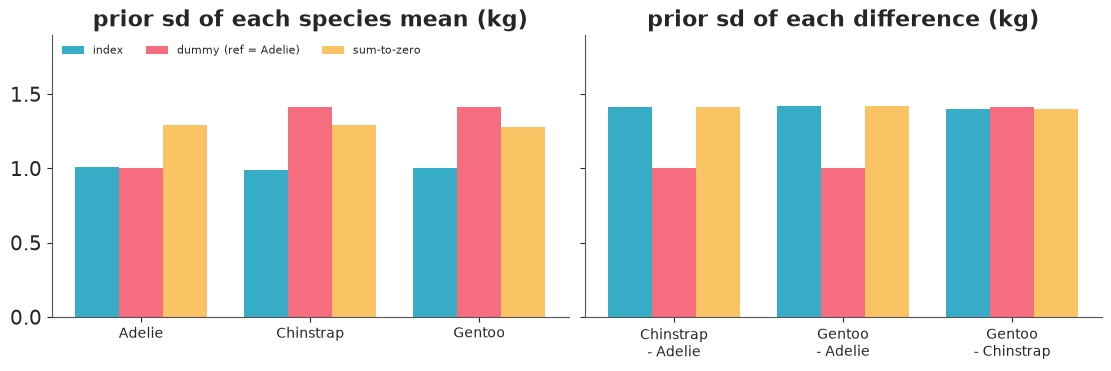

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
width = 0.26
for ax, cols, title in [
    (axes[0], prior_sd.columns[:3], "prior sd of each species mean (kg)"),
    (axes[1], prior_sd.columns[3:], "prior sd of each difference (kg)"),
]:
    for k, coding in enumerate(prior_sd.index):
        ax.bar(np.arange(3) + (k - 1) * width, prior_sd.loc[coding, cols], width, label=coding)
    ticks = [c.replace("sd mean ", "").replace("sd ", "").replace(" - ", "\n- ") for c in cols]
    ax.set_xticks(np.arange(3), ticks, fontsize=10)
    ax.set_title(title)
    ax.set_ylim(0, 1.9)
axes[0].legend(fontsize=8, loc="upper left", ncols=3);

Read the table row by row.

- **Index** coding treats the species exchangeably: every mean has prior sd 1, every
  difference has sd $\sqrt{2} \approx 1.41$.
- **Dummy** coding does not. The reference species has prior sd 1, the others 1.41: the
  model is a priori *more uncertain about Chinstrap and Gentoo than about Adelie*, for no
  better reason than the alphabet. Differences **from** the reference get sd 1, the
  difference **between** two non-reference species gets 1.41. Change the reference level
  and you have changed the model.
- **Sum-to-zero** is symmetric again (means about 1.29 $= \sqrt{1 + 2/3}$, differences
  1.41). It costs one extra line and separates "overall level" from "spread among the
  groups", which is what you want as soon as there are several factors (section 7) or a
  hierarchy on the spread.

None of this is visible in a maximum-likelihood fit, where the three codings give the same
predictions. It becomes visible exactly when the prior has work to do: small groups, many
levels, informative priors. "Try it yourself" 1 lets you measure how small.

### 3.3 Interactions: a combined index or product terms

Species and sex interact (sexual dimorphism differs between species). With index
variables, the interaction is a **two-dimensional parameter indexed by two vectors**:
`mu[species_idx, sex_idx]`. Six cells, six means, one prior each, all exchangeable. The
dummy-coded alternative, `species * sex` in formula notation, builds each cell from up to
four coefficients, so its prior variance depends on how far the cell is from the
reference. No sampling is needed to see that - count the non-zero columns per cell:

In [18]:
cells = pd.DataFrame([(s, x) for s in SPECIES for x in SEXES], columns=["species", "sex"])
X_cells = patsy.dmatrix("species * sex", cells)
print(X_cells.design_info.column_names)
cells.assign(
    n_coefficients=np.asarray(X_cells).sum(axis=1).astype(int),
    prior_sd_if_each_is_N01=np.sqrt((np.asarray(X_cells) ** 2).sum(axis=1)).round(2),
)

['Intercept', 'species[T.Chinstrap]', 'species[T.Gentoo]', 'sex[T.male]', 'species[T.Chinstrap]:sex[T.male]', 'species[T.Gentoo]:sex[T.male]']


,species,sex,n_coefficients,prior_sd_if_each_is_N01
0,Adelie,female,1,1.00
1,Adelie,male,2,1.41
2,Chinstrap,female,2,1.41
3,Chinstrap,male,4,2.00
4,Gentoo,female,2,1.41
5,Gentoo,male,4,2.00


In [19]:
species_idx = encode(peng_sexed.species, SPECIES)
sex_idx = encode(peng_sexed.sex, SEXES)
assert species_idx.min() >= 0 and sex_idx.min() >= 0

with pm.Model(coords={"species": SPECIES, "sex": SEXES}) as m_cells:
    mu = pm.Normal("mu", 4.0, 1.0, dims=("species", "sex"))
    sigma = pm.HalfNormal("sigma", 1.0)
    pm.Normal("mass", mu[species_idx, sex_idx], sigma, observed=peng_sexed.body_mass_g / 1000)
    idata_cells = pm.sample(random_seed=RANDOM_SEED)

mu_post = idata_cells.posterior["mu"]
dimorphism = mu_post.sel(sex="male") - mu_post.sel(sex="female")
print("divergences:", int(idata_cells.sample_stats["diverging"].sum()))
az.summary(xr.Dataset({"mu": mu_post, "male_minus_female": dimorphism}), ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [mu, sigma]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"mu[Adelie, female]",3.37,0.04,3.30,3.44,5519.60,3188.86,1.0,0.0,0.0
"mu[Adelie, male]",4.04,0.04,3.98,4.11,5355.55,3184.59,1.0,0.0,0.0
"mu[Chinstrap, female]",3.53,0.05,3.43,3.63,5345.18,3479.30,1.0,0.0,0.0
"mu[Chinstrap, male]",3.94,0.05,3.84,4.04,5948.50,3241.15,1.0,0.0,0.0
"mu[Gentoo, female]",4.68,0.04,4.60,4.76,5519.33,3307.52,1.0,0.0,0.0
"mu[Gentoo, male]",5.48,0.04,5.41,5.56,6089.75,3284.99,1.0,0.0,0.0
male_minus_female[Adelie],0.67,0.05,0.57,0.77,5873.30,3275.60,1.0,0.0,0.0
male_minus_female[Chinstrap],0.41,0.08,0.27,0.55,5387.53,3039.30,1.0,0.0,0.0
male_minus_female[Gentoo],0.80,0.06,0.70,0.92,5586.26,3153.56,1.0,0.0,0.0


Under product coding with a `Normal(0, 1)` on every coefficient, the prior sd of a cell
mean runs from 1 (Adelie females, the reference cell) to 2 (the males of the two
non-reference species), and the imbalance compounds with every further interacting factor.
The two-dimensional index gives all six cells the same prior, and any contrast is a
subtraction on labelled arrays: males are heavier by about 0.67 kg in Adelies, 0.80 kg in
Gentoos and only about 0.41 kg in Chinstraps, whose 94% interval lies entirely below the
Gentoos'.

(Independent priors per cell mean no sharing of information between cells. When cells are
many and thin, put a hierarchy on them - E02 - but the *indexing* stays exactly like this.)

## 4 · Scaling and centring

Two separate reasons, usually blurred together.

1. **Priors become interpretable and transferable.** `Normal(0, 1)` on the coefficient of
   a standardised predictor says "a one-sd change in x moves y by less than about two sd
   of y". That sentence is true for flipper length in mm, tenure in months and charges in
   dollars alike. The same `Normal(0, 1)` on raw columns is a different, accidental claim
   for each.
2. **The sampler's geometry improves.** NUTS adapts a *diagonal* mass matrix: it learns
   one scale per parameter. It can therefore undo bad **scales** by itself, but not
   **correlations** between parameters - and uncentred predictors tie the intercept to
   every slope, because the intercept lives at x = 0, which for a flipper is 170 mm
   outside the data: tilt the line a little and its value out there swings a lot.

Measure it. Same regression of body mass on three measurements, three preparations, and
both samplers. Wall-clock time on a busy laptop is noisy, so the honest currency is
**gradient evaluations**: leapfrog steps per draw, and effective samples per 1000 gradients.

In [20]:
PREDICTORS = ["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]
X_raw = peng[PREDICTORS].to_numpy()
y_raw = peng.body_mass_g.to_numpy()

x_mean, x_sd = X_raw.mean(axis=0), X_raw.std(axis=0)
y_mean, y_sd = y_raw.mean(), y_raw.std()


def fit_linear(X, y, a_prior, b_sd, sigma_sd, sampler="nutpie"):
    with pm.Model(coords={"predictor": PREDICTORS}):
        a = pm.Normal("a", *a_prior)
        b = pm.Normal("b", 0, b_sd, dims="predictor")
        sigma = pm.HalfNormal("sigma", sigma_sd)
        pm.Normal("y", a + pm.math.dot(X, b), sigma, observed=y)
        return pm.sample(random_seed=RANDOM_SEED, nuts_sampler=sampler, progressbar=False)


def geometry(idata):
    stats = idata.sample_stats
    ess = float(az.ess(idata.posterior.to_dataset()).to_array().min())
    return {
        "step size": float(stats["step_size"].mean()),
        "leapfrog steps / draw": float(stats["n_steps"].mean()),
        "divergences": int(stats["diverging"].sum()),
        "min bulk ESS": ess,
        "ESS / 1000 gradients": 1000 * ess / float(stats["n_steps"].sum()),
        "sampling time (s)": float(idata.posterior.attrs["sampling_time"]),
    }


PREPARATIONS = {
    # weak priors on each scale; with 342 birds the posterior is the same regression in all three
    "raw": (X_raw, y_raw, (0, 10_000), 200, 1000),
    "centred": (X_raw - x_mean, y_raw, (4000, 1000), 200, 1000),
    "standardised": ((X_raw - x_mean) / x_sd, (y_raw - y_mean) / y_sd, (0, 1), 1, 1),
}
fits, report = {}, {}
for sampler in ["nutpie", "pymc"]:
    for prep_name, args in PREPARATIONS.items():
        fits[sampler, prep_name] = fit_linear(*args, sampler=sampler)
        report[sampler, prep_name] = geometry(fits[sampler, prep_name])

pd.DataFrame(report).T.round({"step size": 3, "leapfrog steps / draw": 1, "min bulk ESS": 0,
                              "ESS / 1000 gradients": 1, "sampling time (s)": 1})

NUTS[nutpie]: [a, b, sigma]


NUTS[nutpie]: [a, b, sigma]


NUTS[nutpie]: [a, b, sigma]


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, b, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


step size  leapfrog steps / draw  divergences  \
nutpie raw               0.176                   57.4          0.0   
       centred           0.755                    5.3          0.0   
       standardised      0.749                    5.3          0.0   
pymc   raw               0.039                   93.2          0.0   
       centred           0.789                    5.9          0.0   
       standardised      0.753                    5.9          0.0   

                     min bulk ESS  ESS / 1000 gradients  sampling time (s)  
nutpie raw                  679.0                   3.0                0.2  
       centred             2310.0                 109.2                0.0  
       standardised        1899.0                  89.2                0.0  
pymc   raw                 1269.0                   3.4                3.9  
       centred             3165.0                 133.3                0.8  
       standardised        3246.0                 137.9                0.5

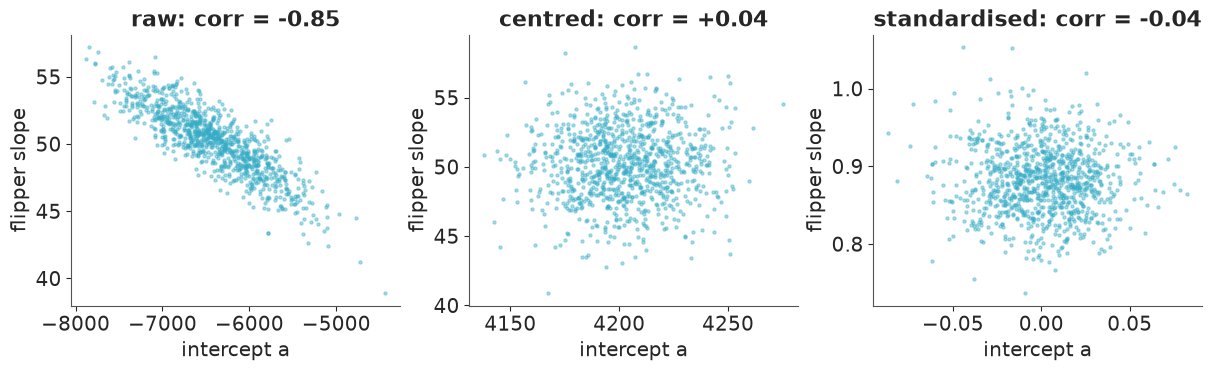

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, prep_name in zip(axes, PREPARATIONS):
    draws = az.extract(fits["nutpie", prep_name], num_samples=1000, random_seed=RANDOM_SEED)
    a_draws, b_draws = draws["a"].values, draws["b"].sel(predictor="flipper_length_mm").values
    ax.scatter(a_draws, b_draws, s=5, alpha=0.4)
    corr = np.corrcoef(a_draws, b_draws)[0, 1]
    ax.set(xlabel="intercept a", ylabel="flipper slope", title=f"{prep_name}: corr = {corr:+.2f}")

No divergences anywhere and (section 4.2) the same posterior: the raw model is not wrong,
it is **expensive**. On raw predictors the step size collapses (about 0.18 with nutpie and
0.04 with PyMC's NUTS, against about 0.75 after centring), each draw needs 60-90 leapfrog
steps instead of 5-6, and the effective sample size per 1000 gradient evaluations falls
from around 100 to about 3 - a factor of thirty or more, with either sampler. The
scatterplots show why: on the raw scale the intercept is pinned to the flipper slope
(correlation -0.85, and it is tied to the other two slopes as well), and its posterior sd
is hundreds of grams instead of about twenty.

The less advertised half of the result: **centring did all of the work.** Standardising on
top of it bought nothing for the sampler, because both samplers learn a per-parameter
scale during warm-up. So: centre for the sampler *and* the prior; scale for the prior.

### 4.1 How to scale

- **Centre** always (on the training mean, or on a meaningful reference value: 200 mm,
  age 40, the year 2000). It makes the intercept the expected outcome for a typical unit,
  which is the only intercept you can put a sensible prior on.
- **Scale by the sd** when predictors have no natural unit or you want one prior for all
  coefficients. **Scale by a meaningful unit** - 10 mm, 1 kg, 12 months - when readers will
  consume the coefficient directly. Both fix the numerics; the second needs no
  back-transformation and does not change when the sample changes.
- **Log** a positive predictor whose effect is proportional ("doubling the dose"), then
  centre the log. Do not standardise a 0/1 indicator: its coefficient is already "the
  difference between the groups".

### 4.2 Back-transforming, with the uncertainty intact

Coefficients on the standardised scale are not reportable. With
$z_j = (x_j - \bar{x}_j)/s_j$ and $y^\ast = (y - \bar{y})/s_y$:

$$
\beta^{\text{raw}}_j = \beta_j \frac{s_y}{s_j}, \qquad
\alpha^{\text{raw}} = \bar{y} + s_y\,\alpha - \sum_j \beta^{\text{raw}}_j \bar{x}_j, \qquad
\sigma^{\text{raw}} = s_y\,\sigma .
$$

The right way is to apply this to **every posterior draw** and summarise afterwards. With
labelled arrays it is three lines. The check is that it reproduces the raw-scale fit.

In [22]:
scale = xr.DataArray(y_sd / x_sd, coords={"predictor": PREDICTORS})
centre = xr.DataArray(x_mean, coords={"predictor": PREDICTORS})

post_z = fits["nutpie", "standardised"].posterior
b_back = post_z["b"] * scale
a_back = y_mean + y_sd * post_z["a"] - (b_back * centre).sum("predictor")
back = xr.Dataset({"a": a_back, "b": b_back, "sigma": y_sd * post_z["sigma"]})

SHOW = ["mean", "sd", "hdi94_lb", "hdi94_ub"]
pd.concat(
    {
        "back-transformed draws": az.summary(back, ci_kind="hdi", ci_prob=0.94, round_to=1)[SHOW],
        "fitted on raw scale": az.summary(fits["nutpie", "raw"], ci_kind="hdi", ci_prob=0.94, round_to=1)[SHOW],
    },
    axis=1,
)

back-transformed draws                           \
                                       mean     sd hdi94_lb hdi94_ub   
a                                   -6418.9  562.0  -7490.5  -5380.6   
b[flipper_length_mm]                   50.2    2.5     45.5     54.8   
b[bill_length_mm]                       4.2    5.3     -5.8     14.2   
b[bill_depth_mm]                       20.0   13.7     -5.0     46.2   
sigma                                 394.8   15.4    367.7    425.6   

                     fitted on raw scale                           
                                    mean     sd hdi94_lb hdi94_ub  
a                                -6403.7  556.7  -7447.8  -5367.6  
b[flipper_length_mm]                50.2    2.5     45.5     54.5  
b[bill_length_mm]                    4.2    5.3     -5.6     14.1  
b[bill_depth_mm]                    19.7   13.7     -5.5     45.1  
sigma                              394.7   15.1    366.3    422.7

The tempting shortcut is to transform the **summary table** instead of the draws: take the
interval endpoints of `a` and `b` on the z-scale and push them through the formula. For a
slope that happens to work (it is a rescaling of one parameter). For the intercept it does
not: $\alpha^{\text{raw}}$ combines four correlated parameters, and interval endpoints do
not combine.

In [23]:
summ_z = az.summary(fits["nutpie", "standardised"], ci_kind="hdi", ci_prob=0.94, round_to=6)
b_lo, b_hi = (summ_z.loc[[f"b[{p}]" for p in PREDICTORS], c].to_numpy() * y_sd / x_sd for c in ["hdi94_lb", "hdi94_ub"])
a_lo, a_hi = (y_mean + y_sd * summ_z.loc["a", c] for c in ["hdi94_lb", "hdi94_ub"])
# "worst case" endpoint arithmetic: what people do when they only have the table
wrong = (a_lo - np.maximum(b_lo * x_mean, b_hi * x_mean).sum(),
         a_hi - np.minimum(b_lo * x_mean, b_hi * x_mean).sum())
right = az.hdi(a_back, prob=0.94).values

print(f"intercept, from summary endpoints (WRONG): [{wrong[0]:8.0f}, {wrong[1]:8.0f}]   width {wrong[1] - wrong[0]:6.0f} g")
print(f"intercept, from transformed draws (RIGHT): [{right[0]:8.0f}, {right[1]:8.0f}]   width {right[1] - right[0]:6.0f} g")
print(f"and the 'intercept' y_mean + y_sd * a = {float(y_mean + y_sd * post_z['a'].mean()):.0f} g"
      " is the mass of an AVERAGE bird, not of one with x = 0")

intercept, from summary endpoints (WRONG): [   -8264,    -4567]   width   3697 g
intercept, from transformed draws (RIGHT): [   -7491,    -5381]   width   2110 g
and the 'intercept' y_mean + y_sd * a = 4202 g is the mass of an AVERAGE bird, not of one with x = 0


The back-transformed draws reproduce the raw-scale fit to within Monte Carlo error (flipper
slope 50.2 g/mm in both, intercept about -6400 g with sd about 560 g), so you can have the
good geometry *and* the reportable units.

The endpoint shortcut gives an interval for the intercept that is about 3700 g wide where
the correct one is about 2100 g: endpoint arithmetic stacks worst cases that the joint
posterior says do not happen together. And the last line is the most common mistake of
all - reporting $\bar{y} + s_y\alpha$ = 4202 g as "the intercept". That is the expected
mass of a bird with average measurements. The raw intercept, about -6400 g, is the mass of
an impossible penguin with zero-length flippers. Both are legitimate; they are different
quantities, and a table must say which one it shows.

### 4.3 The scaler belongs to the training data

The means and sds used for standardising are **part of the fitted model**, exactly like
the coefficients. New rows must be transformed with the *training* constants. Computing
them from the rows you are predicting for is the classic leak, and it fails worst when
the new batch differs from the training data - which is when predictions matter.

Train on the 2007 and 2008 seasons. Next season a colleague sends measurements for the
Gentoo colony only and asks for predicted masses.

In [24]:
train = peng[peng.year < 2009]
batch = peng[(peng.year == 2009) & (peng.species == "Gentoo")]
tr_mean, tr_sd = train[PREDICTORS].mean().to_numpy(), train[PREDICTORS].std(ddof=0).to_numpy()
ty_mean, ty_sd = train.body_mass_g.mean(), train.body_mass_g.std(ddof=0)

idata_train = fit_linear(
    (train[PREDICTORS].to_numpy() - tr_mean) / tr_sd, (train.body_mass_g.to_numpy() - ty_mean) / ty_sd, (0, 1), 1, 1
)
draws = az.extract(idata_train, num_samples=1000, random_seed=RANDOM_SEED)


def predict_g(X_new, mean, sd):
    """Posterior-mean prediction in grams, standardising X_new with the given constants."""
    z = (X_new - mean) / sd
    mu_z = draws["a"].values[None, :] + z @ draws["b"].transpose("predictor", "sample").values
    return ty_mean + ty_sd * mu_z.mean(axis=1)


X_batch, y_batch = batch[PREDICTORS].to_numpy(), batch.body_mass_g.to_numpy()
versions = {
    "RIGHT: training mean/sd": predict_g(X_batch, tr_mean, tr_sd),
    "WRONG: mean/sd of the whole table (computed before the split)": predict_g(X_batch, x_mean, x_sd),
    "WRONG: the batch's own mean/sd": predict_g(X_batch, X_batch.mean(axis=0), X_batch.std(axis=0)),
}
print(f"{len(train)} training birds (mean mass {ty_mean:.0f} g),",
      f"{len(batch)} new Gentoos (mean mass {y_batch.mean():.0f} g)\n")
for label, pred_g in versions.items():
    rmse = np.sqrt(np.mean((pred_g - y_batch) ** 2))
    print(f"{label:<62} mean prediction {pred_g.mean():5.0f} g   RMSE {rmse:5.0f} g")

NUTS[nutpie]: [a, b, sigma]


223 training birds (mean mass 4197 g), 43 new Gentoos (mean mass 5141 g)

RIGHT: training mean/sd                                        mean prediction  5086 g   RMSE   307 g
WRONG: mean/sd of the whole table (computed before the split)  mean prediction  5038 g   RMSE   320 g
WRONG: the batch's own mean/sd                                 mean prediction  4197 g   RMSE  1100 g


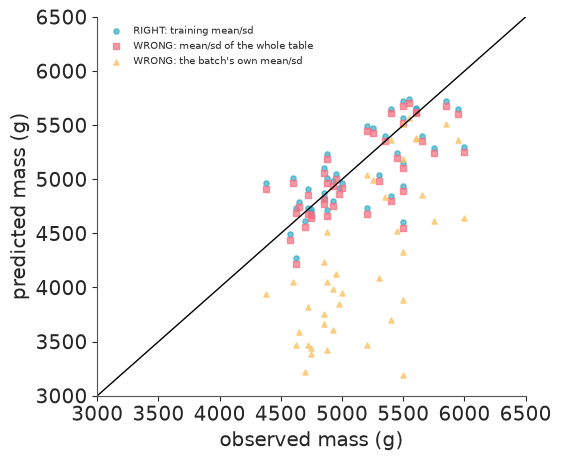

In [25]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for (label, pred_g), marker in zip(versions.items(), ["o", "s", "^"]):
    ax.scatter(y_batch, pred_g, s=14, alpha=0.7, marker=marker, label=label.split(" (")[0])
lims = [3000, 6500]
ax.plot(lims, lims, color="k", lw=1)
ax.set(xlabel="observed mass (g)", ylabel="predicted mass (g)", xlim=lims, ylim=lims)
ax.legend(fontsize=7);

With the training constants the model does a decent job on birds from a season it never
saw (RMSE about 310 g). Standardising with the **whole table's** mean and sd is only
slightly worse here (about 320 g), because those happen to be close to the training
values - but it is still information from rows you claim not to have seen, and how much it
hurts is not under your control. Standardising the batch **by its own statistics** is a
disaster: RMSE about 1100 g. It tells the model "these are average penguins" - so the
predictions average 4197 g, exactly the training mean, for the heaviest species in the
data. Nothing crashes, and every prediction is a plausible penguin.

## 5 · Transforming the outcome

Transforming $y$ is not preparation in the same sense as scaling $x$: it **changes the
likelihood**. `Normal` on $\log y$ *is* a `LogNormal` model for $y$: errors become
multiplicative, the variance grows with the mean, and every coefficient turns from "adds
so many grams" into "multiplies by so much".

| Transform | Implied model for y | A coefficient b means | Usually better |
|---|---|---|---|
| none | Normal, constant sd | + b units | - |
| `log y` | LogNormal, constant *relative* sd | x exp(b) | `Gamma` / `LogNormal` / `NegativeBinomial` with a log link |
| `logit y` | logit-Normal on (0, 1) | x exp(b) on the odds | `Beta`, or `Binomial` if y is k out of n |
| `sqrt y` | variance roughly proportional to the mean | awkward | `Poisson` / `NegativeBinomial` |

The last column is the advice: **pick a likelihood whose support matches the data** and
keep $y$ in its own units. `log(0)` and `logit(1)` then never come up, predictions are on
the scale people ask about, and model comparison stays honest (an `elpd` for $\log y$ and
one for $y$ differ by a Jacobian and cannot be compared).

A log transform does have a clean reading when both sides are logged - the slope is an
**elasticity**. Penguins are roughly geometric objects, so mass should scale like length
cubed:

In [26]:
log_flipper_c = np.log(peng.flipper_length_mm / 200).to_numpy()   # centred on a meaningful 200 mm
sp_idx = encode(peng.species, SPECIES)

with pm.Model(coords={"species": SPECIES}) as m_loglog:
    a = pm.Normal("a", np.log(4000), 0.5, dims="species")      # log-grams at 200 mm
    elasticity = pm.Normal("elasticity", 3, 2)                  # prior centred on isometric scaling
    sigma = pm.HalfNormal("sigma", 0.5)
    pm.Normal("log_mass", a[sp_idx] + elasticity * log_flipper_c, sigma, observed=np.log(peng.body_mass_g))
    idata_loglog = pm.sample(random_seed=RANDOM_SEED)

ratio = np.exp(idata_loglog.posterior["a"].sel(species="Gentoo") - idata_loglog.posterior["a"].sel(species="Adelie"))
az.summary(xr.Dataset({"elasticity": idata_loglog.posterior["elasticity"], "sigma": idata_loglog.posterior["sigma"],
                       "gentoo_vs_adelie_ratio": ratio}), ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [a, elasticity, sigma]


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
elasticity,1.90,0.15,1.61,2.17,1489.13,1820.67,1.0,0.0,0.0
sigma,0.09,0.00,0.09,0.10,3937.70,3210.92,1.0,0.0,0.0
gentoo_vs_adelie_ratio,1.07,0.02,1.02,1.11,1382.99,1829.69,1.0,0.0,0.0


The statements a log outcome buys are *relative*: within a species, a 1% longer flipper
goes with about 1.9% more mass (94% HDI roughly 1.6-2.2) - well short of the isometric 3
the prior was centred on, which the data overruled without difficulty (a flipper is not a
body length). At equal flipper length a Gentoo is about 7% heavier than an Adelie. And
`sigma` of 0.09 is a scatter of about 9% of a bird's mass, whatever its size.

### 5.1 The retransformation trap

Someone will ask for the answer in dollars, not log-dollars. $\exp(\text{mean of } \log y)$
is the **median** of a log-normal, not its mean; the mean is $\exp(\mu + \sigma^2/2)$. For
the penguins $\sigma = 0.09$, the two differ by 0.4% and nobody would notice. Telco's
`TotalCharges` is another matter. Fit the textbook model - Normal on the log, one mean and
sd per contract type - to the billed customers, and ask for the **average total charge per
contract**, three ways.

In [27]:
CONTRACTS = ["Month-to-month", "One year", "Two year"]
billed = telco[telco.tenure > 0].reset_index(drop=True)      # log(0) is the transform telling you something
contract_idx = encode(billed.Contract, CONTRACTS)
assert contract_idx.min() >= 0

with pm.Model(coords={"contract": CONTRACTS}) as m_lognormal:
    mu = pm.Normal("mu", 7, 2, dims="contract")
    sigma = pm.HalfNormal("sigma", 2, dims="contract")
    pm.Normal("log_total", mu[contract_idx], sigma[contract_idx], observed=np.log(billed.TotalCharges))
    idata_ln = pm.sample(random_seed=RANDOM_SEED)
    # posterior predictive on a thinned posterior: 400 replicated datasets of 7032 customers
    ppc = pm.sample_posterior_predictive(idata_ln.isel(draw=slice(None, None, 10)), random_seed=RANDOM_SEED)

log_rep = ppc.posterior_predictive["log_total"].stack(sample=("chain", "draw")).values      # (customer, sample)
post = idata_ln.posterior
retrans = pd.DataFrame(index=CONTRACTS)
retrans["observed mean"] = billed.groupby("Contract").TotalCharges.mean()
retrans["observed median"] = billed.groupby("Contract").TotalCharges.median()
retrans["exp(mean of mu)  [WRONG]"] = np.exp(post["mu"].mean(("chain", "draw"))).values
retrans["exp(mean of log y_rep)  [WRONG]"] = [np.exp(log_rep[contract_idx == k].mean()) for k in range(3)]
retrans["mean of exp(log y_rep)  [RIGHT]"] = [np.exp(log_rep[contract_idx == k]).mean() for k in range(3)]
retrans["sigma"] = post["sigma"].mean(("chain", "draw")).values
retrans.round({"sigma": 2} | {c: 0 for c in retrans.columns[:-1]})

NUTS[nutpie]: [mu, sigma]


Sampling: [log_total]


,observed mean,observed median,exp(mean of mu) [WRONG],exp(mean of log y_rep) [WRONG],mean of exp(log y_rep) [RIGHT],sigma
Month-to-month,1369.0,680.0,544.0,543.0,1922.0,1.59
One year,3035.0,2658.0,1963.0,1955.0,3700.0,1.13
Two year,3729.0,3624.0,2577.0,2576.0,4258.0,1.00


The two `exp(mean ...)` columns say the average month-to-month customer has paid about
\$540. The observed average is \$1369: **2.5 times more**. Exponentiating a mean of logs
gives the *geometric* mean - the median, if the log-normal were true - and with `sigma`
of 1.6 that is nowhere near the arithmetic mean. Averaging **after** exponentiating each
posterior predictive draw is the correct operation.

But look at what the correct operation returns: \$1920, **40% too high**. That is not a
retransformation error any more; it is the model. The log-normal mean
$\exp(\mu + \sigma^2/2)$ leans entirely on the right tail being log-normal, and it is not
(left panel of the figure below: log-charges are left-skewed and stop dead where the
72-month maximum tenure caps them; the observed medians are not close to the geometric
means either). On the log scale that misfit looks cosmetic. Exponentiated, it is \$550 per
customer. The alternative is a likelihood on the dollar scale whose **mean is a parameter**:

In [28]:
with pm.Model(coords={"contract": CONTRACTS}) as m_gamma:
    log_mean = pm.Normal("log_mean", 7, 2, dims="contract")
    shape = pm.Exponential("shape", 1, dims="contract")
    mean = pm.Deterministic("mean", pm.math.exp(log_mean), dims="contract")     # the estimand, by construction
    pm.Gamma("total", alpha=shape[contract_idx], beta=shape[contract_idx] / mean[contract_idx],
             observed=billed.TotalCharges)
    idata_gamma = pm.sample(random_seed=RANDOM_SEED)

retrans["Gamma, log link: posterior mean of `mean`"] = idata_gamma.posterior["mean"].mean(("chain", "draw")).values
retrans[["observed mean", "mean of exp(log y_rep)  [RIGHT]", "Gamma, log link: posterior mean of `mean`"]].round(0)

NUTS[nutpie]: [log_mean, shape]


,observed mean,mean of exp(log y_rep) [RIGHT],"Gamma, log link: posterior mean of `mean`"
Month-to-month,1369.0,1922.0,1370.0
One year,3035.0,3700.0,3038.0
Two year,3729.0,4258.0,3729.0


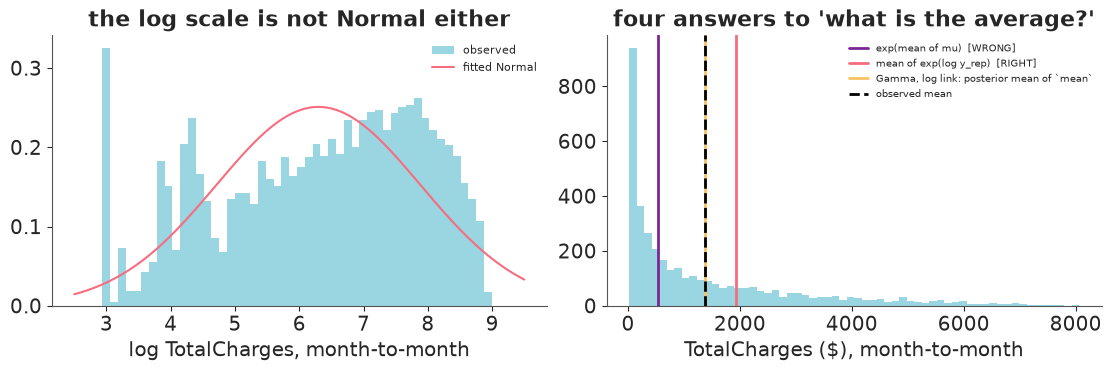

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
m2m = billed.TotalCharges[billed.Contract == "Month-to-month"]
axes[0].hist(np.log(m2m), bins=50, density=True, alpha=0.5, label="observed")
grid = np.linspace(2.5, 9.5, 200)
mu0 = float(post["mu"].sel(contract="Month-to-month").mean())
s0 = float(post["sigma"].sel(contract="Month-to-month").mean())
normal_pdf = np.exp(-0.5 * ((grid - mu0) / s0) ** 2) / (s0 * np.sqrt(2 * np.pi))
axes[0].plot(grid, normal_pdf, color="C1", label="fitted Normal")
axes[0].set(xlabel="log TotalCharges, month-to-month", title="the log scale is not Normal either")
axes[0].legend(fontsize=8)
axes[1].hist(m2m, bins=60, alpha=0.5)
for col, color, ls in [("exp(mean of mu)  [WRONG]", "C3", "-"), ("mean of exp(log y_rep)  [RIGHT]", "C1", "-"),
                       ("Gamma, log link: posterior mean of `mean`", "C2", "-"), ("observed mean", "k", "--")]:
    axes[1].axvline(retrans.loc["Month-to-month", col], color=color, lw=2, ls=ls, label=col)
axes[1].set(xlabel="TotalCharges ($), month-to-month", title="four answers to 'what is the average?'")
axes[1].legend(fontsize=7);

The Gamma model with a log link recovers the observed means to within a few dollars, with no
retransformation step to get wrong - the estimand *is* a parameter. It is also robust in a
way the log-normal is not: for a Gamma with a log link the likelihood equations for the
group means are solved by the sample means whatever the shape parameter does, so getting
the *shape* of the distribution wrong does not bias the *mean*. That is the practical case
for "likelihood that matches the support, plus a link function" over "transform and hope".
(If the question were about the median or a tail quantile, the distributional shape would
matter again, for both models.)

## 6 · Design matrices

Index vectors are the right tool for factors. For several continuous predictors, splines
and their interactions, a **design matrix** `X` with `pm.math.dot(X, beta)` is tidier. By
hand it is `np.column_stack`; the bookkeeping - which column is what - is on you:

In [30]:
X_hand = np.column_stack([
    (peng_sexed.species == "Chinstrap").astype(float),
    (peng_sexed.species == "Gentoo").astype(float),
    (peng_sexed.sex == "male").astype(float),
    (peng_sexed.flipper_length_mm - 200) / 10,
])
names_hand = ["species:Chinstrap", "species:Gentoo", "sex:male", "flipper_per_10mm"]
X_hand[:3], names_hand

(array([[ 0. ,  0. ,  1. , -1.9],
        [ 0. ,  0. ,  0. , -1.4],
        [ 0. ,  0. ,  0. , -0.5]]),
 ['species:Chinstrap', 'species:Gentoo', 'sex:male', 'flipper_per_10mm'])

`patsy` builds the same thing from a formula, names the columns, and - the part that
matters for section 4.3 - its transforms are **stateful**: `center()`, `standardize()` and
the spline basis `bs()` remember the training mean, sd and knots inside `design_info`, and
`build_design_matrices` re-applies *those* to new rows. Unseen factor levels raise an error
instead of becoming -1.

In [31]:
FORMULA = "0 + C(species, levels=SPECIES) + C(sex, levels=SEXES) + bs(flipper_length_mm, df=4)"
dm = patsy.dmatrix(FORMULA, peng_sexed)


def tidy(name):
    """patsy column names -> something you want to read in az.summary."""
    for old, new in [("C(species, levels=SPECIES)", "species"), ("C(sex, levels=SEXES)", "sex"),
                     ("bs(flipper_length_mm, df=4)", "flipper_spline"), ("[T.", ":"), ("[", ":"), ("]", "")]:
        name = name.replace(old, new)
    return name


X_spline = np.asarray(dm)
spline_names = [tidy(n) for n in dm.design_info.column_names]
print(X_spline.shape, spline_names)

new_rows = pd.DataFrame({"species": ["Gentoo"] * 2, "sex": ["female"] * 2, "flipper_length_mm": [210.0, 225.0]})
print(np.asarray(patsy.build_design_matrices([dm.design_info], new_rows)[0]).round(3))
try:
    patsy.build_design_matrices([dm.design_info], new_rows.assign(species="Emperor"))
except patsy.PatsyError as err:
    print("PatsyError:", str(err).splitlines()[0])

(333, 8) ['species:Adelie', 'species:Chinstrap', 'species:Gentoo', 'sex:male', 'flipper_spline:0', 'flipper_spline:1', 'flipper_spline:2', 'flipper_spline:3']
[[0.    0.    1.    0.    0.078 0.367 0.499 0.056]
 [0.    0.    1.    0.    0.002 0.047 0.393 0.559]]
PatsyError: Error converting data to categorical: observation with value 'Emperor' does not match any of the expected levels (expected: ['Adelie', 'Chinstrap', 'Gentoo'])


### 6.1 Check the rank before the sampler tells you the hard way

A design matrix whose columns are linearly dependent has a **ridge** in its likelihood:
infinitely many coefficient vectors give identical predictions. A Bayesian model still has
a proper posterior - the prior closes off the ridge - so nothing crashes. You just get slow
sampling, huge posterior sds and coefficients that mean nothing individually. The textbook
way to get there is an intercept **plus a dummy for every level**:

In [32]:
def check_design(X, names):
    """Rank, condition number, and the linear combination of columns that is (nearly) zero."""
    X = np.asarray(X, dtype=float)
    sv = np.linalg.svd(X / np.linalg.norm(X, axis=0), compute_uv=False)    # scale-free: columns to unit length
    rank = np.linalg.matrix_rank(X)
    print(f"columns {X.shape[1]}, rank {rank}, condition number {sv[0] / sv[-1]:.3g}")
    if rank < X.shape[1]:
        null = np.linalg.svd(X)[2][-1]
        null = null / np.abs(null).max()
        terms = " ".join(f"{w:+.2f}*{n}" for w, n in zip(null, names) if abs(w) > 1e-8)
        print("  redundant combination:", terms, "= 0")




n = len(peng_sexed)
species_dummies = np.column_stack([(peng_sexed.species == s).astype(float) for s in SPECIES])
flipper_10 = ((peng_sexed.flipper_length_mm - 200) / 10).to_numpy()[:, None]

designs = {
    "full rank: one column per species": (np.hstack([species_dummies, flipper_10]), SPECIES + ["flipper_per_10mm"]),
    "redundant: intercept + one column per species": (
        np.hstack([np.ones((n, 1)), species_dummies, flipper_10]), ["intercept"] + SPECIES + ["flipper_per_10mm"]),
}
for label, (X, names) in designs.items():
    print(label)
    check_design(X, names)
print("\nnear-collinearity shows up the same way - the uncentred design of section 4:")
check_design(np.column_stack([np.ones(len(X_raw)), X_raw]), ["intercept"] + PREDICTORS)
check_design(np.column_stack([np.ones(len(X_raw)), (X_raw - x_mean) / x_sd]), ["intercept"] + PREDICTORS)

full rank: one column per species
columns 4, rank 4, condition number 3.97
redundant: intercept + one column per species
columns 5, rank 4, condition number 8.58e+14
  redundant combination: +1.00*intercept -1.00*Adelie -1.00*Chinstrap -1.00*Gentoo = 0

near-collinearity shows up the same way - the uncentred design of section 4:
columns 4, rank 4, condition number 70.7
columns 4, rank 4, condition number 2.95


What does the sampler make of the redundant design? Fit both with the same weak priors.

In [33]:
mass_kg = (peng_sexed.body_mass_g / 1000).to_numpy()
fits_design, report_design = {}, {}
for label, (X, names) in designs.items():
    with pm.Model(coords={"column": names}):
        beta = pm.Normal("beta", 0, 5, dims="column")
        sigma = pm.HalfNormal("sigma", 1)
        pm.Normal("mass", pm.math.dot(X, beta), sigma, observed=mass_kg)
        fits_design[label] = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    report_design[label] = geometry(fits_design[label])

pd.DataFrame(report_design).T.round(2)

NUTS[nutpie]: [beta, sigma]


NUTS[nutpie]: [beta, sigma]


,step size,leapfrog steps / draw,divergences,min bulk ESS,ESS / 1000 gradients,sampling time (s)
full rank: one column per species,0.67,5.78,0.0,1702.66,73.63,0.04
redundant: intercept + one column per species,0.09,87.54,0.0,191.02,0.55,0.42


In [34]:
bad = fits_design["redundant: intercept + one column per species"]
az.summary(bad, var_names=["beta"], ci_kind="hdi", ci_prob=0.94, round_to=2)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta[intercept],3.22,2.47,-0.90,7.76,191.02,218.75,1.02,0.18,0.15
beta[Adelie],0.89,2.47,-3.66,5.02,191.17,219.82,1.02,0.18,0.15
beta[Chinstrap],0.68,2.47,-3.86,4.84,191.37,221.34,1.02,0.18,0.15
beta[Gentoo],1.17,2.47,-3.37,5.34,191.03,218.08,1.02,0.18,0.15
beta[flipper_per_10mm],0.41,0.03,0.35,0.46,1398.95,1605.70,1.01,0.00,0.00


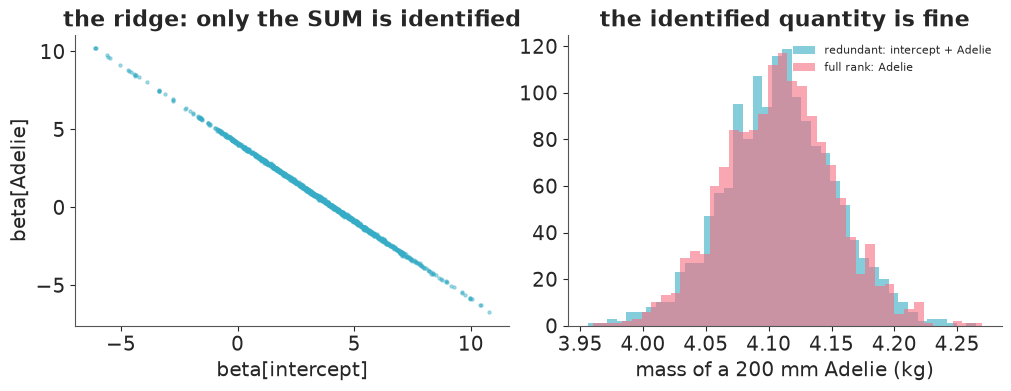

In [35]:
draws = az.extract(bad, num_samples=1500, random_seed=RANDOM_SEED)["beta"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].scatter(draws.sel(column="intercept"), draws.sel(column="Adelie"), s=5, alpha=0.4)
axes[0].set(xlabel="beta[intercept]", ylabel="beta[Adelie]", title="the ridge: only the SUM is identified")
adelie_redundant = (draws.sel(column="intercept") + draws.sel(column="Adelie")).values
axes[1].hist(adelie_redundant, bins=40, alpha=0.6, label="redundant: intercept + Adelie")
good = az.extract(fits_design["full rank: one column per species"], num_samples=1500, random_seed=RANDOM_SEED)["beta"]
axes[1].hist(good.sel(column="Adelie").values, bins=40, alpha=0.6, label="full rank: Adelie")
axes[1].set(xlabel="mass of a 200 mm Adelie (kg)", title="the identified quantity is fine")
axes[1].legend(fontsize=8);

`check_design` flagged it before any sampling: 5 columns, rank 4, a condition number of
about $10^{15}$, and the singular vector names the culprit -
`intercept - Adelie - Chinstrap - Gentoo = 0`. It costs a millisecond.

The sampler, by contrast, does not fail. **Zero divergences.** It takes nearly 90 leapfrog
steps per draw instead of 6, delivers a minimum ESS of about 190 instead of 1700 with
`r_hat` of 1.02, and so produces **over a hundred times fewer effective samples per
gradient**. The species coefficients come out with a posterior sd of about 2.5 kg - that
is the prior talking, along the ridge in the left panel - while the quantity the data
identify, intercept + Adelie, has exactly the posterior it has in the full-rank model
(right panel), and the flipper slope is untouched. That is why redundant designs survive
in production: predictions are fine; only the coefficient table is meaningless and the
run is slow. The signature is *slow + huge sds + pairwise correlation of -1*, not
divergences.

The last two lines of the check are section 4 again: with columns scaled to unit length,
the uncentred design has a condition number of about 70 against 3 for the standardised
one. Collinearity with the intercept is a mild version of the same disease.

### 6.2 A spline model with readable output

Pass the (tidied) column names as a coordinate and `az.summary` reads like a regression
table. Spline coefficients have no individual meaning, so the fitted **curve** is what
to look at - built for new flipper lengths with `build_design_matrices`, which reuses the
training knots.

In [36]:
with pm.Model(coords={"column": spline_names}) as m_spline:
    beta = pm.Normal("beta", 0, 5, dims="column")
    sigma = pm.HalfNormal("sigma", 1)
    pm.Normal("mass", pm.math.dot(X_spline, beta), sigma, observed=mass_kg)
    idata_spline = pm.sample(random_seed=RANDOM_SEED)

check_design(X_spline, spline_names)
az.summary(idata_spline, ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [beta, sigma]


columns 8, rank 8, condition number 28.6


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta[species:Adelie],3.22,0.19,2.87,3.55,628.21,894.75,1.01,0.01,0.00
beta[species:Chinstrap],3.14,0.19,2.78,3.47,626.12,880.09,1.00,0.01,0.00
beta[species:Gentoo],4.00,0.22,3.58,4.39,595.53,805.74,1.00,0.01,0.01
beta[sex:male],0.52,0.04,0.45,0.59,2546.41,2424.94,1.00,0.00,0.00
beta[flipper_spline:0],0.06,0.27,-0.45,0.54,669.67,1015.58,1.00,0.01,0.01
beta[flipper_spline:1],0.33,0.19,0.00,0.70,1236.63,1634.85,1.00,0.01,0.00
beta[flipper_spline:2],0.88,0.32,0.29,1.47,673.82,974.64,1.00,0.01,0.01
beta[flipper_spline:3],1.20,0.24,0.76,1.63,696.30,853.73,1.01,0.01,0.01
sigma,0.30,0.01,0.27,0.32,3985.26,2495.44,1.00,0.00,0.00


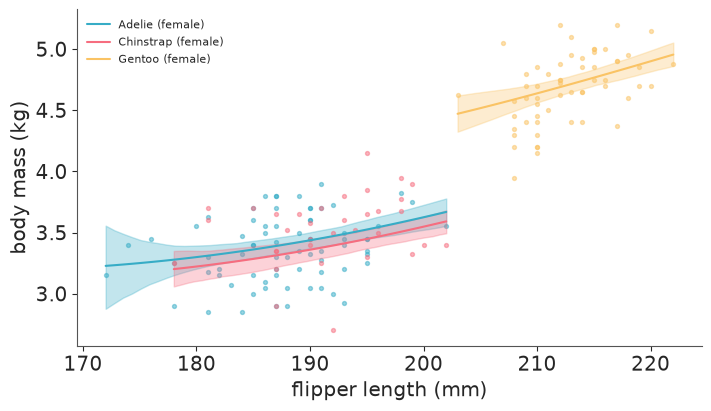

In [37]:
beta_draws = az.extract(idata_spline, num_samples=1000, random_seed=RANDOM_SEED)["beta"]
beta_draws = beta_draws.transpose("column", "sample").values
fig, ax = plt.subplots(figsize=(7, 4))
for k, sp in enumerate(SPECIES):
    sub = peng_sexed[(peng_sexed.species == sp) & (peng_sexed.sex == "female")]
    flipper_grid = np.linspace(sub.flipper_length_mm.min(), sub.flipper_length_mm.max(), 40)
    grid = pd.DataFrame({"species": sp, "sex": "female", "flipper_length_mm": flipper_grid})
    mu_grid = np.asarray(patsy.build_design_matrices([dm.design_info], grid)[0]) @ beta_draws
    ax.fill_between(grid.flipper_length_mm, *np.quantile(mu_grid, [0.03, 0.97], axis=1), color=f"C{k}", alpha=0.3)
    ax.plot(grid.flipper_length_mm, mu_grid.mean(axis=1), color=f"C{k}", label=f"{sp} (female)")
    ax.scatter(sub.flipper_length_mm, sub.body_mass_g / 1000, color=f"C{k}", s=8, alpha=0.5)
ax.set(xlabel="flipper length (mm)", ylabel="body mass (kg)")
ax.legend(fontsize=8);

The summary reads like a regression table because the names travelled with the matrix.
Within a species the spline finds little beyond a straight line, and the band opens up
where birds are scarce (the few Adelies under 178 mm). The condition number of about 29 is
worth a glance: B-spline columns nearly sum to one, so they are partly collinear with the
species columns, which is why both sets of coefficients have a much lower ESS than
`sex:male` or `sigma`.
Harmless here; with more knots you would want a smoothing prior on the spline
coefficients rather than independent Normals (E05 covers smooth functions properly).

## 7 · Sufficient statistics: let the table do the work

NUTS evaluates the likelihood of **every row** at **every gradient step**. When all the
predictors are categorical, thousands of rows share a handful of distinct covariate
combinations, and rows in the same cell have the same probability $p$. The product of
$n$ Bernoulli terms with a common $p$ is one Binomial term (up to a constant that does not
involve the parameters): the pair *(customers, churners)* per cell is a **sufficient
statistic**. Same posterior, a fraction of the arithmetic.

A churn model on five categorical predictors. Each factor gets sum-to-zero effects around
an intercept - with several factors, that is what keeps the intercept identified (compare
section 6.1: one free mean per level of *every* factor plus an intercept is the redundant
design again).

In [38]:
FACTORS = {
    "Contract": ["Month-to-month", "One year", "Two year"],
    "InternetService": ["DSL", "Fiber optic", "No"],
    "PaymentMethod": ["Bank transfer (automatic)", "Credit card (automatic)", "Electronic check", "Mailed check"],
    "PaperlessBilling": ["No", "Yes"],
    "SeniorCitizen": ["No", "Yes"],
}
for f, levels in FACTORS.items():
    assert set(telco[f]) == set(levels), f

cell_table = telco.groupby(list(FACTORS), as_index=False).agg(
    customers=("churned", "size"), churners=("churned", "sum")
)
n_possible = np.prod([len(v) for v in FACTORS.values()])
print(f"{len(telco)} customers -> {len(cell_table)} non-empty cells (of {n_possible} possible)")
cell_table.sort_values("customers", ascending=False).head()

7043 customers -> 135 non-empty cells (of 144 possible)


,Contract,InternetService,PaymentMethod,PaperlessBilling,SeniorCitizen,customers,churners
26,Month-to-month,Fiber optic,Electronic check,Yes,No,689,431
27,Month-to-month,Fiber optic,Electronic check,Yes,Yes,371,236
10,Month-to-month,DSL,Electronic check,Yes,No,244,104
41,Month-to-month,No,Mailed check,No,No,227,40
131,Two year,No,Mailed check,No,No,194,1


In [39]:
def churn_model(table, aggregated):
    idx = {f: encode(table[f], levels) for f, levels in FACTORS.items()}
    assert all(i.min() >= 0 for i in idx.values())
    with pm.Model(coords=FACTORS) as m:
        eta = pm.Normal("intercept", 0, 1.5)
        for f in FACTORS:
            eta = eta + pm.ZeroSumNormal(f"b_{f}", 1.0, dims=f)[idx[f]]
        if aggregated:
            pm.Binomial("churners", n=table.customers.to_numpy(), logit_p=eta, observed=table.churners.to_numpy())
        else:
            pm.Bernoulli("churned", logit_p=eta, observed=table.churned.to_numpy())
    return m


timing = {}
fits_churn = {}
runs = [("Bernoulli, 7043 rows", telco, False), (f"Binomial, {len(cell_table)} cells", cell_table, True)]
for label, table, aggregated in runs:
    start = time.perf_counter()
    with churn_model(table, aggregated):
        fits_churn[label] = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    timing[label] = {
        "rows in the likelihood": len(table),
        "wall time incl. compile (s)": time.perf_counter() - start,
        "sampling time (s)": fits_churn[label].posterior.attrs["sampling_time"],
        "leapfrog steps / draw": float(fits_churn[label].sample_stats["n_steps"].mean()),
        "divergences": int(fits_churn[label].sample_stats["diverging"].sum()),
    }
timing = pd.DataFrame(timing).T
speed_up = timing["sampling time (s)"].iloc[0] / timing["sampling time (s)"].iloc[1]
print(f"sampling is {speed_up:.0f}x faster on the aggregated table")
timing.round(1)

NUTS[nutpie]: [intercept, b_Contract, b_InternetService, b_PaymentMethod, b_PaperlessBilling, b_SeniorCitizen]


NUTS[nutpie]: [intercept, b_Contract, b_InternetService, b_PaymentMethod, b_PaperlessBilling, b_SeniorCitizen]


sampling is 23x faster on the aggregated table


,rows in the likelihood,wall time incl. compile (s),sampling time (s),leapfrog steps / draw,divergences
"Bernoulli, 7043 rows",7043.0,5.8,4.4,7.6,0.0
"Binomial, 135 cells",135.0,1.6,0.2,7.5,0.0


largest difference in posterior means: 0.072 posterior sd (intercept)
largest ratio of posterior sds:        1.047


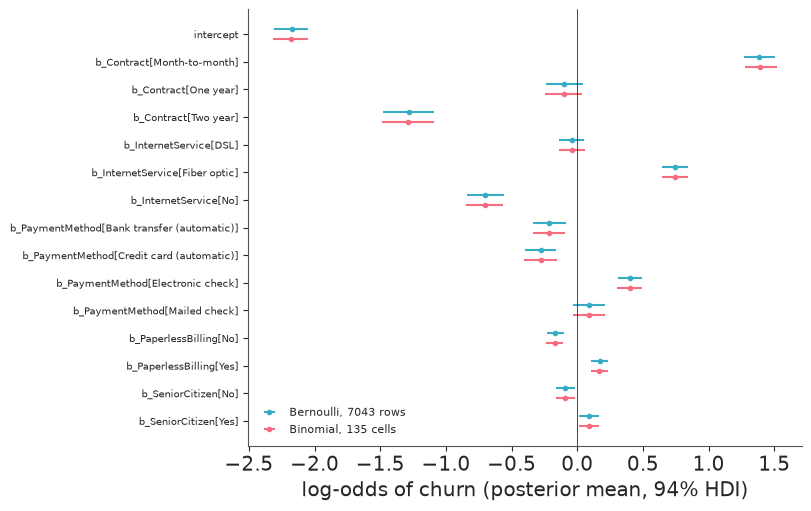

In [40]:
summaries = {label: az.summary(idata, ci_kind="hdi", ci_prob=0.94, round_to=3) for label, idata in fits_churn.items()}
(row_label, s_row), (cell_label, s_cell) = summaries.items()
gap = ((s_row["mean"] - s_cell["mean"]).abs() / s_row["sd"])
print(f"largest difference in posterior means: {gap.max():.3f} posterior sd ({gap.idxmax()})")
print(f"largest ratio of posterior sds:        {(s_cell['sd'] / s_row['sd']).max():.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ypos = np.arange(len(s_row))
for k, (label, s) in enumerate(summaries.items()):
    ax.errorbar(s["mean"], ypos + 0.18 * (2 * k - 1), xerr=[s["mean"] - s["hdi94_lb"], s["hdi94_ub"] - s["mean"]],
                fmt="o", ms=3, label=label)
ax.set_yticks(ypos, s_row.index, fontsize=7)
ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.5)
ax.set(xlabel="log-odds of churn (posterior mean, 94% HDI)")
ax.legend(fontsize=8);

135 rows instead of 7043. The number of leapfrog steps per draw is the same for both -
the posterior is the same, so its geometry is the same - but each gradient touches fifty
times fewer rows. Sampling (nutpie) is tens of times faster: the printed ratio has been
between 20x and 50x across our runs, depending on what else the machine was doing. The
wall-time column is diluted by compilation, which aggregation does not speed up. The posterior means agree
to within a small fraction of a posterior sd and the sds to within a few percent: Monte
Carlo noise. The churn story itself is familiar - month-to-month contracts, fibre and
electronic cheques push churn up - and is not the point here.

When this applies: every predictor is categorical (or can be binned without regret) and
the likelihood has a sufficient statistic. Bernoulli -> Binomial(n, k); Poisson -> Poisson
of the summed count with summed exposure; Normal with known groups -> n, mean and sum of
squares. What you give up: anything per row. Posterior predictive checks and LOO are now
per *cell*, and one continuous predictor (tenure, charges) shatters the cells - see
"Try it yourself" 3.

## 8 · One `prepare()` function, with assertions at the door

Everything so far - declared levels, training-set scalers, index vectors, coords - needs
to happen **identically** for the training data, the test data and next year's data. The
way to guarantee that is one function that does it, returning one small object, and a
`validate()` that refuses to hand a broken object to the model. Each assertion below is a
bug that otherwise fails *silently* or with an unreadable PyTensor traceback.

In [41]:
@dataclass
class Prepared:
    y: np.ndarray | None          # outcome in kg (None when predicting)
    X: np.ndarray                 # standardised predictors, float64, (n, p)
    idx: dict                     # {"species": int array, "sex": int array}
    coords: dict                  # obs, predictor, species, sex
    scalers: dict                 # training mean/sd per predictor - part of the fitted model


LEVELS = {"species": SPECIES, "sex": SEXES}


def prepare(df, scalers=None):
    """Table -> arrays, index vectors, coords. Pass the training `scalers` for any later table."""
    if scalers is None:     # training: learn the constants here, and only here
        scalers = {"mean": df[PREDICTORS].mean().to_dict(), "sd": df[PREDICTORS].std(ddof=0).to_dict()}
    X = np.column_stack([(df[p].to_numpy(dtype="float64") - scalers["mean"][p]) / scalers["sd"][p] for p in PREDICTORS])
    prep = Prepared(
        y=df.body_mass_g.to_numpy(dtype="float64") / 1000 if "body_mass_g" in df else None,
        X=X,
        idx={f: encode(df[f], levels) for f, levels in LEVELS.items()},
        coords={"obs": df.index.to_numpy(), "predictor": PREDICTORS, **LEVELS},
        scalers=scalers,
    )
    validate(prep)
    return prep


def validate(prep):
    n = len(prep.coords["obs"])
    p = len(prep.coords["predictor"])
    assert len(np.unique(prep.coords["obs"])) == n, "obs labels are not unique (index not reset after a merge?)"
    assert prep.X.shape == (n, p), f"X is {prep.X.shape}, expected {(n, p)}"
    assert prep.X.dtype == np.float64, f"X has dtype {prep.X.dtype} (object dtype means strings or None got in)"
    n_bad = int((~np.isfinite(prep.X)).sum())
    assert n_bad == 0, f"{n_bad} NaN/inf values in X: a NaN predictor is NOT imputed, it turns logp into NaN"
    assert all(sd > 0 for sd in prep.scalers["sd"].values()), "a predictor is constant in the training data"
    for f, codes in prep.idx.items():
        assert np.issubdtype(codes.dtype, np.integer), f"{f} index has dtype {codes.dtype}; indices must be integers"
        assert len(codes) == n, f"{f} index has length {len(codes)}, expected {n}"
        assert codes.min() >= 0, (f"{int((codes < 0).sum())} rows have a {f} that is missing or not in "
                                  f"{prep.coords[f]}; -1 would index the LAST level")
        assert codes.max() < len(prep.coords[f]), f"{f} index out of range"
    if prep.y is not None:
        assert prep.y.shape == (n,) and np.isfinite(prep.y).all(), "outcome misaligned or not finite"
        assert 1 < prep.y.mean() < 10, "outcome should be in kg - unit error?"


test_rows = rng.choice(len(peng_sexed), size=len(peng_sexed) // 5, replace=False)
is_test = np.isin(np.arange(len(peng_sexed)), test_rows)
train_df, test_df = peng_sexed[~is_test], peng_sexed[is_test]

train_prep = prepare(train_df)
test_prep = prepare(test_df, scalers=train_prep.scalers)
print(len(train_df), "train,", len(test_df), "test")
print("training scalers:", {k: {p: round(v, 2) for p, v in d.items()} for k, d in train_prep.scalers.items()})
print("test X column means (NOT zero, and should not be):", test_prep.X.mean(axis=0).round(2))

267 train, 66 test
training scalers: {'mean': {'flipper_length_mm': 200.8, 'bill_length_mm': 43.88, 'bill_depth_mm': 17.23}, 'sd': {'flipper_length_mm': 13.99, 'bill_length_mm': 5.52, 'bill_depth_mm': 1.92}}
test X column means (NOT zero, and should not be): [ 0.06  0.1  -0.18]


Now feed it the tables that real projects produce.

In [42]:
broken = {
    "a species the model has never seen": test_df.assign(species="Emperor"),
    "sex missing in one row": test_df.assign(sex=lambda d: d.sex.where(d.index != d.index[0])),
    "NaN in a predictor": test_df.assign(bill_depth_mm=lambda d: d.bill_depth_mm.where(d.index != d.index[0])),
    "numbers stored as text, one blank": test_df.assign(
        flipper_length_mm=lambda d: d.flipper_length_mm.astype(str).where(d.index != d.index[0], " ")),
    "duplicated rows after a bad merge": pd.concat([test_df, test_df.iloc[:3]]),
}
for label, frame in broken.items():
    try:
        prepare(frame, scalers=train_prep.scalers)
        print(f"{label:<36} -> passed (!)")
    except (AssertionError, ValueError) as err:
        print(f"{label:<36} -> {type(err).__name__}: {str(err)[:95]}")

a species the model has never seen   -> AssertionError: 66 rows have a species that is missing or not in ['Adelie', 'Chinstrap', 'Gentoo']; -1 would in
sex missing in one row               -> AssertionError: 1 rows have a sex that is missing or not in ['female', 'male']; -1 would index the LAST level
NaN in a predictor                   -> AssertionError: 1 NaN/inf values in X: a NaN predictor is NOT imputed, it turns logp into NaN
numbers stored as text, one blank    -> ValueError: could not convert string to float: ' '
duplicated rows after a bad merge    -> AssertionError: obs labels are not unique (index not reset after a merge?)


Two more that `validate` cannot see because they happen *before* it, both from pandas
doing what it was told:

- **Float indices.** An integer column that acquires one `NaN` (after a left merge, a
  `reindex`, a `where`) silently becomes `float64`. PyTensor refuses to index with floats
  (`TypeError: index must be integers or a boolean mask`), and the error appears where the
  model is built, far from the merge that caused it.
- **Integer overflow.** Narrow integer types from databases and parquet files wrap around
  without a word in array arithmetic.

In [43]:
codes = pd.Series([0, 2, 1])
after_merge = codes.reindex([0, 1, 2, 3])        # one unmatched row
print("index dtype before / after the merge:", codes.dtype, "/", after_merge.dtype)

exposure = np.array([70_000], dtype="int32")      # e.g. customers x days
print("70000 * 70000 in int32:", exposure * exposure, "  in int64:", exposure.astype("int64") ** 2)

index dtype before / after the merge: int64 / float64
70000 * 70000 in int32: [605032704]   in int64: [4900000000]


### 8.1 The model: `pm.Data` for every input

The plumbing rules for a model you will predict from:

- every input that changes between training and prediction is a **`pm.Data`** with
  `dims="obs"`;
- the likelihood gets **`shape=mu.shape`** so it resizes with the data;
- `pm.set_data` replaces **all** of them at once together with the new **`obs` coords**;
- assert afterwards that what came back lines up with what went in.

In [44]:
with pm.Model(coords=train_prep.coords) as m_final:
    X = pm.Data("X", train_prep.X, dims=("obs", "predictor"))
    sp = pm.Data("species_idx", train_prep.idx["species"], dims="obs")
    sx = pm.Data("sex_idx", train_prep.idx["sex"], dims="obs")

    cell = pm.Normal("cell", 4.0, 1.0, dims=("species", "sex"))        # kg, at average measurements
    beta = pm.Normal("beta", 0, 0.5, dims="predictor")                 # kg per training sd
    sigma = pm.HalfNormal("sigma", 0.5)

    mu = cell[sp, sx] + pm.math.dot(X, beta)
    pm.Normal("mass", mu, sigma, observed=train_prep.y, dims="obs", shape=mu.shape)
    idata_final = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(idata_final.sample_stats["diverging"].sum()))
az.summary(idata_final, ci_kind="hdi", ci_prob=0.94, round_to=3)

NUTS[nutpie]: [cell, beta, sigma]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"cell[Adelie, female]",3.736,0.070,3.614,3.872,1303.319,1795.032,1.003,0.002,0.001
"cell[Adelie, male]",4.193,0.068,4.070,4.322,1517.314,2041.215,1.001,0.002,0.001
"cell[Chinstrap, female]",3.602,0.065,3.487,3.732,2570.212,2886.273,1.003,0.001,0.001
"cell[Chinstrap, male]",3.714,0.082,3.566,3.871,1765.748,2142.986,1.001,0.002,0.001
"cell[Gentoo, female]",4.565,0.092,4.395,4.737,1390.499,1768.958,1.000,0.002,0.002
"cell[Gentoo, male]",5.079,0.092,4.900,5.242,1181.555,1902.506,1.002,0.003,0.002
beta[flipper_length_mm],0.230,0.044,0.146,0.314,1286.951,1758.908,1.003,0.001,0.001
beta[bill_length_mm],0.133,0.040,0.058,0.207,1436.914,2008.992,1.003,0.001,0.001
beta[bill_depth_mm],0.095,0.042,0.015,0.174,1512.894,1862.517,1.003,0.001,0.001
sigma,0.273,0.013,0.249,0.296,5282.034,2736.619,1.001,0.000,0.000


In [45]:
with m_final:
    pm.set_data(
        {"X": test_prep.X, "species_idx": test_prep.idx["species"], "sex_idx": test_prep.idx["sex"]},
        coords={"obs": test_prep.coords["obs"]},
    )
    pred = pm.sample_posterior_predictive(idata_final, predictions=True, random_seed=RANDOM_SEED)

pred_mass = pred.predictions["mass"]
assert pred_mass.sizes["obs"] == len(test_df)
assert (pred_mass.obs.values == test_df.index.to_numpy()).all(), "predictions are not aligned with the test rows"

pred_mean = pred_mass.mean(("chain", "draw")).values
lo, hi = np.quantile(pred_mass.stack(sample=("chain", "draw")).values, [0.05, 0.95], axis=1)
rmse_g = 1000 * np.sqrt(np.mean((pred_mean - test_prep.y) ** 2))
print(f"test RMSE: {rmse_g:.0f} g   (posterior sigma: {1000 * float(idata_final.posterior['sigma'].mean()):.0f} g)")
covered = (test_prep.y >= lo) & (test_prep.y <= hi)
print(f"90% predictive interval covers {covered.sum()} of {len(test_df)} held-out birds ({covered.mean():.0%})")

Sampling: [mass]


test RMSE: 303 g   (posterior sigma: 273 g)
90% predictive interval covers 55 of 66 held-out birds (83%)


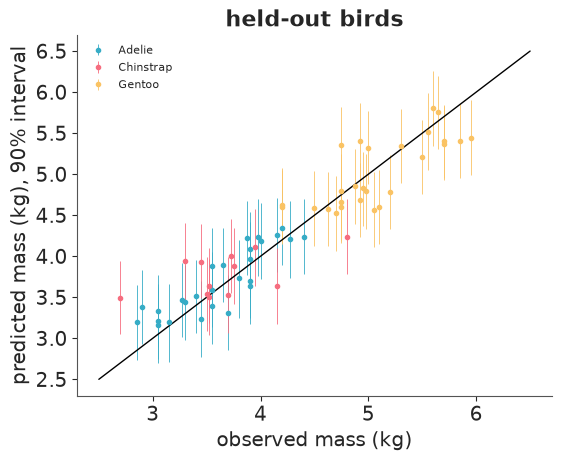

In [46]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for k, sp_name in enumerate(SPECIES):
    sel = test_prep.idx["species"] == k
    ax.errorbar(test_prep.y[sel], pred_mean[sel], yerr=[pred_mean[sel] - lo[sel], hi[sel] - pred_mean[sel]],
                fmt="o", ms=3, lw=0.6, color=f"C{k}", label=sp_name)
ax.plot([2.5, 6.5], [2.5, 6.5], color="k", lw=1)
ax.set(xlabel="observed mass (kg)", ylabel="predicted mass (kg), 90% interval", title="held-out birds")
ax.legend(fontsize=8);

The held-out RMSE (about 300 g) is close to the posterior `sigma` (about 270 g), as it
should be when the model is not overfitting. The 90% interval covers 55 of the 66 held-out
birds, 83%: with 66 birds the sampling sd of that percentage is just under 4 points, so
this is on the low side without being alarming. The two assertions are the part to copy:
`pred_mass.obs` carries the **labels** of the test rows, so predictions can be joined back
to the table by label, not by position and hope.

## 9 · Persist the fit *with* its preparation

A posterior for `beta` is uninterpretable without the constants that defined `X`. Six
months from now the DataFrame will have changed and the notebook will not rerun. Store the
scalers, the declared levels and the package versions **inside the file**, in `attrs`. A
`DataTree` writes itself with `to_netcdf`; `az.from_netcdf` reads it back. netCDF
attributes must be strings or numbers, so nested dictionaries go through JSON.

In [47]:
idata_final.attrs["preparation"] = json.dumps({
    "scalers": train_prep.scalers,
    "levels": LEVELS,
    "outcome": "body_mass_g / 1000 (kg)",
    "rows": "penguins_raw, complete cases for measurements and sex, 80% random split, seed 42",
})
idata_final.attrs["versions"] = json.dumps(
    {"pymc": pm.__version__, "arviz": az.__version__, "pandas": pd.__version__, "numpy": np.__version__}
)

with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "penguin_mass_fit.nc"
    idata_final.to_netcdf(path)
    print(f"{path.name}: {path.stat().st_size / 1e6:.2f} MB")
    loaded = az.from_netcdf(path).load()      # .load() pulls everything into memory so the file can go away

print(type(loaded).__name__, list(loaded.children))
print("posterior identical:", bool((loaded.posterior["beta"] == idata_final.posterior["beta"]).all()),
      "| coords survive:", loaded.posterior.species.values.tolist(), loaded.posterior.predictor.values.tolist())
stored = json.loads(loaded.attrs["preparation"])
print("scalers identical: ", stored["scalers"] == train_prep.scalers)
print("versions:", loaded.attrs["versions"])

penguin_mass_fit.nc: 0.95 MB
DataTree ['posterior', 'sample_stats', 'constant_data', 'observed_data']
posterior identical: True | coords survive: ['Adelie', 'Chinstrap', 'Gentoo'] ['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']
scalers identical:  True
versions: {"pymc": "6.3.2", "arviz": "1.3.0", "pandas": "3.0.6", "numpy": "2.5.3"}


From the file alone, the coefficients can be reported in units a biologist recognises:

In [48]:
sd = xr.DataArray([stored["scalers"]["sd"][p] for p in PREDICTORS], coords={"predictor": PREDICTORS})
beta_g_per_mm = 1000 * loaded.posterior["beta"] / sd
az.summary(xr.Dataset({"grams_per_mm": beta_g_per_mm}), ci_kind="hdi", ci_prob=0.94, round_to=1)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
grams_per_mm[flipper_length_mm],16.5,3.2,10.4,22.4,1287.0,1758.9,1.0,0.1,0.1
grams_per_mm[bill_length_mm],24.1,7.2,10.6,37.5,1436.9,2009.0,1.0,0.2,0.1
grams_per_mm[bill_depth_mm],49.3,22.0,7.8,90.6,1512.9,1862.5,1.0,0.6,0.4


The round trip returns a `DataTree` with identical draws, labelled coordinates and the
preparation. Two details cost time if you do not know them: a **dict in `attrs` fails** on
write with an unhelpful `TypeError: Object dtype ... has no native HDF5 equivalent` (hence
JSON), and `az.from_netcdf` reads lazily, so `.load()` before the file disappears. The
`constant_data` group already holds the exact `X` and index vectors the model was fitted
to, which makes a good audit trail. What is *not* in the file is the model itself: keep
the code that builds it under version control, next to the `prepare()` that feeds it.

## 10 · The checklist

**Before cleaning**
- [ ] Audit table: dtype, missing, **blank**, distinct values per column. Numeric columns
  typed as text are hiding something.
- [ ] What is a row? Find the key, assert it is unique, check for repeated units and
  natural groups (nests, customers, sites).
- [ ] Constant columns define the population. Write the population down, then drop them.

**Cleaning**
- [ ] Rename with an explicit dictionary; keep units in names; assert the schema.
- [ ] Parse dates with an explicit format. Coerce text to numbers, then **look at what was coerced**.
- [ ] Range-check against physical limits. Decide what each blank *means* (missing, zero, not applicable).
- [ ] Missingness triage: how much, where, related to what? Write down what complete-case analysis assumes (-> D02).

**Encoding**
- [ ] **Declare** the levels of every factor; encode every table against the declaration; assert no -1.
- [ ] Index variables by default. Know what your coding says about the prior on group *differences*.
- [ ] Interactions as a multi-dimensional parameter indexed by several vectors.

**Scaling**
- [ ] Centre every continuous predictor; scale by sd or by a meaningful unit; log what is multiplicative.
- [ ] Scalers come from the **training rows only** and are stored with the fit.
- [ ] Back-transform **draws**, never summaries. The standardised intercept is not the raw intercept.

**Outcome**
- [ ] Prefer a likelihood that matches the support over a transformed outcome.
- [ ] If you transform: report means from `mean(g_inverse(y_rep))`, never `g_inverse(mean)`.

**Design**
- [ ] Rank and condition number of `X` before sampling. Intercept + all dummies = ridge.
- [ ] Column names as a coord. Stateful transforms (patsy `design_info`) for new rows.
- [ ] All-categorical predictors and a big table? Aggregate to sufficient statistics.

**Plumbing**
- [ ] One `prepare()`; one `validate()`: finite floats, integer in-range indices, equal
  lengths, unique obs labels, units.
- [ ] `pm.Data` for every input, `shape=mu.shape`, `set_data` with new coords, assert alignment of predictions.
- [ ] `to_netcdf` with scalers, levels and versions in `attrs`.

### Try it yourself

1. **Make the coding matter.** Section 3.2 showed the three codings differ in the prior.
   Keep only 3 birds per species (`peng.groupby("species").sample(3, random_state=1)`), fit
   the index, dummy and sum-to-zero models with the sd-1 priors, and compare the posterior
   of Gentoo - Chinstrap. How large must the groups be before the coding stops mattering?
2. **A unit instead of an sd.** Rewrite `prepare()` to scale flipper length by 10 mm and
   the bill measurements by 1 mm, centred on fixed reference values. Which priors on `beta`
   express the same belief as `Normal(0, 0.5)` per sd? What no longer needs storing, and
   what do you lose?
3. **Aggregate a model with a continuous predictor.** Add `tenure` to the churn model of
   section 7. Aggregation now needs bins: try 6-month bins with the bin midpoint as the
   predictor, compare the posterior with the row-level fit, and find the bin width at
   which the approximation becomes visible.

Next: **D02** treats missing data properly - what this notebook only triaged.